# ACME v3.0

Running all FM216 experiments…

=== Quadratic cond=10 ===
 Trial 1/3
 Trial 2/3
 Trial 3/3


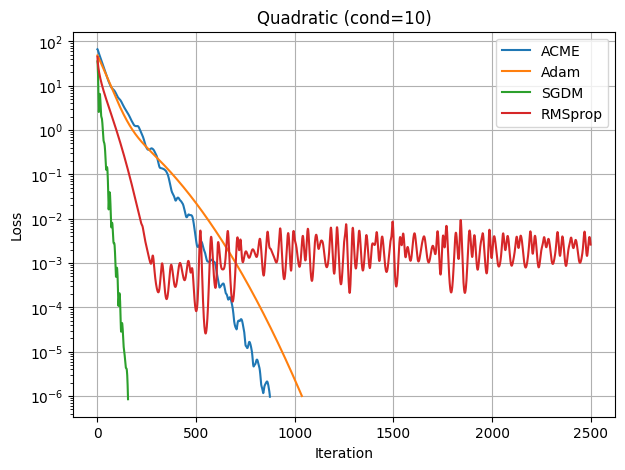


=== Quadratic cond=100 ===
 Trial 1/3
 Trial 2/3
 Trial 3/3


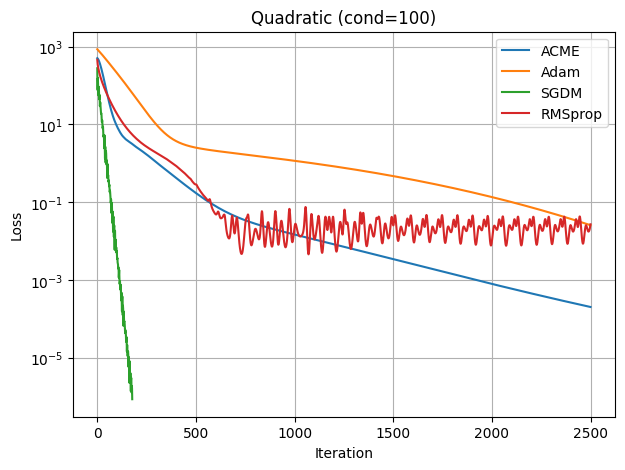


=== Rosenbrock ===


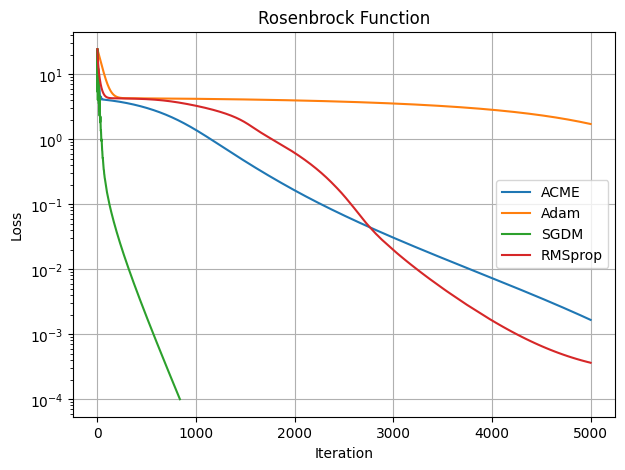


=== MNIST MLP ===

Optimizer: ACME
Epoch 01: loss=0.4652, acc=0.9367
Epoch 02: loss=0.3380, acc=0.9344
Epoch 03: loss=0.2958, acc=0.9408
Epoch 04: loss=0.2723, acc=0.9375
Epoch 05: loss=0.2467, acc=0.9410
Epoch 06: loss=0.2332, acc=0.9365
Epoch 07: loss=0.2273, acc=0.9521
Epoch 08: loss=0.2293, acc=0.9526
Epoch 09: loss=0.2200, acc=0.9494
Epoch 10: loss=0.2294, acc=0.9437
Epoch 11: loss=0.2199, acc=0.9513
Epoch 12: loss=0.2260, acc=0.9485
Epoch 13: loss=0.2181, acc=0.9460
Epoch 14: loss=0.2095, acc=0.9531
Epoch 15: loss=0.2093, acc=0.9508
Epoch 16: loss=0.2198, acc=0.9426
Epoch 17: loss=0.2148, acc=0.9493
Epoch 18: loss=0.2089, acc=0.9438
Epoch 19: loss=0.2050, acc=0.9438
Epoch 20: loss=0.2168, acc=0.9446

Optimizer: Adam
Epoch 01: loss=0.3465, acc=0.9517
Epoch 02: loss=0.1442, acc=0.9656
Epoch 03: loss=0.0985, acc=0.9677
Epoch 04: loss=0.0754, acc=0.9713
Epoch 05: loss=0.0571, acc=0.9756
Epoch 06: loss=0.0469, acc=0.9740
Epoch 07: loss=0.0383, acc=0.9768
Epoch 08: loss=0.0303, acc=0.

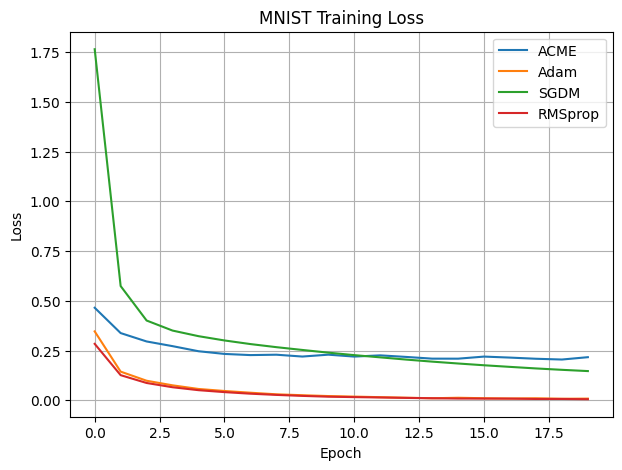

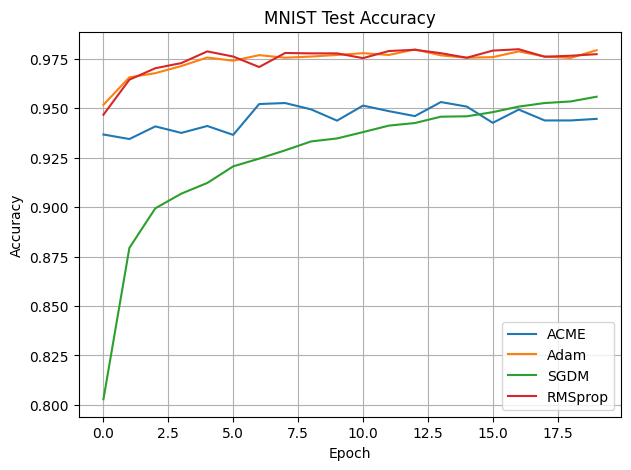


All experiments completed!


In [4]:
# ================================================================
# FM216 PROJECT – FINAL COMPLETE EXPERIMENT SUITE
# ACME-XL Optimizer (Full Mode + Safe Mode)
# Adam, SGD+Momentum, RMSprop Baselines
# ================================================================

import math
import time
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (7, 5)

# ================================================================
# Device + Seed
# ================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(BASE_SEED)


# ================================================================
# ACME-XL OPTIMIZER (FINAL FIXED)
# ================================================================
class ACME_XL(torch.optim.Optimizer):
    def __init__(
        self,
        params,
        lr=1e-3,
        betamin=0.7,
        betamax=0.95,
        beta2=0.999,
        rho=0.9999,
        gamma=0.5,
        eta=0.1,
        lambda_r=1.0,
        lambda_d=1.0,
        alpha_sgd=3e-4,
        beta_sgd=0.9,
        kappa_beta=0.99,
        alpha_c=0.3,
        xi=0.3,
        zeta=0.1,
        eps=1e-8,
        delta=1e-12,
        delta_c=1e-12,
        newton_clip=None,
    ):
        defaults = dict(
            lr=lr,
            betamin=betamin,
            betamax=betamax,
            beta2=beta2,
            rho=rho,
            gamma=gamma,
            eta=eta,
            lambda_r=lambda_r,
            lambda_d=lambda_d,
            alpha_sgd=alpha_sgd,
            beta_sgd=beta_sgd,
            kappa_beta=kappa_beta,
            alpha_c=alpha_c,
            xi=xi,
            zeta=zeta,
            eps=eps,
            delta=delta,
            delta_c=delta_c,
            newton_clip=newton_clip,
        )
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        if closure:
            with torch.enable_grad():
                closure()

        for group in self.param_groups:

            lr = group["lr"]
            betamin = group["betamin"]
            betamax = group["betamax"]
            beta2 = group["beta2"]
            rho = group["rho"]
            gamma = group["gamma"]
            eta = group["eta"]
            lambda_r = group["lambda_r"]
            lambda_d = group["lambda_d"]
            alpha_sgd = group["alpha_sgd"]
            beta_sgd = group["beta_sgd"]
            kappa_beta = group["kappa_beta"]
            alpha_c = group["alpha_c"]
            xi = group["xi"]
            zeta = group["zeta"]
            eps = group["eps"]
            delta = group["delta"]
            delta_c = group["delta_c"]
            newton_clip = group["newton_clip"]

            # step counter
            t = group.get("step", 0) + 1
            group["step"] = t

            # collect gradients
            grads = []
            for p in group["params"]:
                if p.grad is not None:
                    grads.append(p.grad.detach().reshape(-1))
            if len(grads) == 0:
                continue
            g = torch.cat(grads)

            # previous gradient
            prev_g = group.get("prev_g", None)
            if prev_g is None:
                c_t = g.new_tensor(1.0)
                d_t = g.new_tensor(1.0)
            else:
                dot = torch.dot(prev_g, g)
                ng = torch.norm(g)
                npg = torch.norm(prev_g)
                c_t = dot / (ng * npg + delta_c)
                c_t = torch.clamp(c_t, -1, 1)
                d_t = ng / (npg + delta)

            group["prev_g"] = g.clone()

            # angle-magnitude
            a_t = max(0.0, float(c_t))
            q_t = 1.0 / (1.0 + lambda_d * abs(d_t - 1.0))
            phi_t = max(0.0, min(1.0, a_t * q_t))
            beta_base = betamin + (betamax - betamin) * phi_t

            # kurtosis EMAs
            E2 = group.get("E2", torch.zeros(1, device=g.device))
            E4 = group.get("E4", torch.zeros(1, device=g.device))
            E2 = kappa_beta * E2 + (1 - kappa_beta) * (g**2).mean()
            E4 = kappa_beta * E4 + (1 - kappa_beta) * (g**4).mean()
            group["E2"], group["E4"] = E2, E4

            kurt = E4 / (E2**2 + delta)
            excess = max(0.0, float(kurt - 3.0))
            h_scalar = 1.0 / (1.0 + eta * excess)

            # update v, u, z
            for p in group["params"]:
                if p.grad is None:
                    continue
                grad = p.grad
                s = self.state[p]
                if len(s) == 0:
                    s["m"] = torch.zeros_like(p.data)
                    s["v"] = torch.zeros_like(p.data)
                    s["u"] = torch.zeros_like(p.data)
                    s["z"] = torch.zeros_like(p.data)

                s["v"].mul_(beta2).addcmul_(grad, grad, value=1 - beta2)
                s["u"].mul_(rho).addcmul_(grad, grad, value=1 - rho)
                s["z"].mul_(beta_sgd).add_(grad, alpha=1 - beta_sgd)

            # curvature ratio
            ratios = []
            for p in group["params"]:
                if p.grad is None:
                    continue
                s = self.state[p]
                v_hat = s["v"] / (1 - beta2**t)
                u_hat = s["u"] / (1 - rho**t)
                ratios.append(((v_hat + delta) / (u_hat + delta)).reshape(-1))
            r_mean = torch.cat(ratios).mean()

            c_stab = torch.exp(-lambda_r * abs(torch.log(r_mean + delta)))

            # *** FIXED CLAMP ***
            a_t_clamped = max(0.0, min(1.0, float(a_t)))
            C_t = float(a_t_clamped * float(c_stab))

            beta_t = float(beta_base + alpha_c * C_t * (1 - beta_base))

            B = group.get("B", 1.0)
            B *= beta_t
            group["B"] = B
            denom_m = 1.0 - B + 1e-16

            lr_boost = 1.0 + xi * C_t

            # final update
            for p in group["params"]:
                if p.grad is None:
                    continue
                grad = p.grad
                s = self.state[p]

                m = s["m"]
                v = s["v"]
                u = s["u"]
                z = s["z"]

                m.mul_(beta_t).add_(grad, alpha=1 - beta_t)
                m_hat = m / denom_m

                v_hat = v / (1 - beta2**t)
                u_hat = u / (1 - rho**t)

                r = (v_hat + delta) / (u_hat + delta)
                a_curv = torch.pow(r, -gamma)
                s_total = a_curv * h_scalar

                adapt = lr * lr_boost * s_total * m_hat / (torch.sqrt(u_hat) + eps)

                s_stab = torch.exp(-lambda_r * abs(torch.log(r + delta)))
                w = 1 - s_stab

                sgd = alpha_sgd * z

                second = zeta * C_t * (m_hat / (u_hat + eps))
                if newton_clip is not None:
                    second = torch.clamp(second, -newton_clip, newton_clip)

                update = w * adapt + (1 - w) * sgd + second
                p.data.add_(-update)

        return None


# ================================================================
# Quadratic Helpers
# ================================================================
def make_spd_matrix(dim=20, cond=10):
    V, _ = np.linalg.qr(np.random.randn(dim, dim))
    eigs = np.linspace(1, cond, dim)
    return V @ np.diag(eigs) @ V.T


# ================================================================
# Quadratic Runner (ACME FULL MODE)
# ================================================================
def run_quadratic(cond, dim=20, trials=3, max_iter=2500, tol=1e-6):

    print(f"\n=== Quadratic cond={cond} ===")

    def fn(x, Q): return 0.5 * (x @ Q @ x)

    OPTS = {
        "ACME": lambda p: ACME_XL(p,
            lr=1e-2,
            zeta=0.12,
            newton_clip=None,
            betamin=0.6,
            betamax=0.98,
            xi=0.3),
        "Adam": lambda p: torch.optim.Adam(p, lr=1e-2),
        "SGDM": lambda p: torch.optim.SGD(p, lr=1e-2, momentum=0.9),
        "RMSprop": lambda p: torch.optim.RMSprop(p, lr=1e-2)
    }

    logs = {k: [] for k in OPTS}

    for trial in range(trials):
        print(f" Trial {trial+1}/{trials}")
        Q_np = make_spd_matrix(dim, cond)
        Q = torch.tensor(Q_np, dtype=torch.float32, device=device)

        for name, ctor in OPTS.items():
            x = torch.randn(dim, device=device, requires_grad=True)
            opt = ctor([x])

            losses = []
            for it in range(max_iter):
                opt.zero_grad()
                L = fn(x, Q)
                losses.append(L.item())
                if L.item() < tol:
                    break
                L.backward()
                opt.step()

            logs[name].append(losses)

    for name in OPTS:
        plt.plot(logs[name][0], label=name)
    plt.yscale("log")
    plt.title(f"Quadratic (cond={cond})")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    return logs


# ================================================================
# Rosenbrock Runner (ACME FULL MODE)
# ================================================================
def run_rosen(max_iter=5000, tol=1e-4, trials=3):

    print("\n=== Rosenbrock ===")

    def rosen_fn(p):
        x, y = p[0], p[1]
        return (1 - x)**2 + 100*(y - x**2)**2

    OPTS = {
        "ACME": lambda p: ACME_XL(p,
            lr=1e-3,
            zeta=0.12,
            newton_clip=None,
            betamin=0.6,
            betamax=0.98,
            xi=0.3),
        "Adam": lambda p: torch.optim.Adam(p, lr=1e-3),
        "SGDM": lambda p: torch.optim.SGD(p, lr=1e-3, momentum=0.9),
        "RMSprop": lambda p: torch.optim.RMSprop(p, lr=1e-3),
    }

    logs = {k: [] for k in OPTS}

    for trial in range(trials):

        for name, ctor in OPTS.items():
            p = torch.tensor([-1.2, 1.0], device=device, requires_grad=True)
            opt = ctor([p])

            losses = []
            for it in range(max_iter):
                opt.zero_grad()
                L = rosen_fn(p)
                losses.append(L.item())
                if L.item() < tol:
                    break
                L.backward()
                opt.step()

            logs[name].append(losses)

    for name in OPTS:
        plt.plot(logs[name][0], label=name)
    plt.yscale("log")
    plt.title("Rosenbrock Function")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    return logs


# ================================================================
# MNIST Runner (ACME SAFE MODE)
# ================================================================
class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784,128)
        self.fc2 = nn.Linear(128,64)
        self.fc3 = nn.Linear(64,10)

    def forward(self,x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

def mnist_loaders(bs=64):
    tf = transforms.ToTensor()
    train = datasets.MNIST("./data", train=True, download=True, transform=tf)
    test  = datasets.MNIST("./data", train=False, download=True, transform=tf)
    return (
        DataLoader(train, bs, shuffle=True),
        DataLoader(test, bs, shuffle=False)
    )

def train_epoch(model, opt, loader):
    model.train()
    total = 0; count = 0
    for x,y in loader:
        x,y = x.to(device),y.to(device)
        opt.zero_grad()
        out = model(x)
        loss = F.cross_entropy(out,y)
        loss.backward()
        opt.step()
        total += loss.item()*x.size(0)
        count += x.size(0)
    return total/count

@torch.no_grad()
def test(model, loader):
    model.eval()
    total = 0
    correct = 0
    for x,y in loader:
        x,y = x.to(device),y.to(device)
        out = model(x)
        pred = out.argmax(1)
        correct += (pred==y).sum().item()
        total += y.size(0)
    return correct/total

def run_mnist(epochs=20, lr=1e-3):

    print("\n=== MNIST MLP ===")

    train_loader, test_loader = mnist_loaders()

    OPTS = {
        "ACME": lambda p: ACME_XL(p,
            lr=5e-4,
            zeta=0.05,
            newton_clip=0.02,
            betamin=0.7,
            betamax=0.95,
            xi=0.2),
        "Adam": lambda p: torch.optim.Adam(p, lr=lr),
        "SGDM": lambda p: torch.optim.SGD(p, lr=lr, momentum=0.9),
        "RMSprop": lambda p: torch.optim.RMSprop(p, lr=lr),
    }

    results = {}

    for name, ctor in OPTS.items():
        print(f"\nOptimizer: {name}")

        set_seed(BASE_SEED + 500)
        model = MNISTNet().to(device)
        opt = ctor(model.parameters())

        train_l, accs = [], []

        for e in range(epochs):
            tr = train_epoch(model, opt, train_loader)
            ac = test(model, test_loader)
            train_l.append(tr)
            accs.append(ac)
            print(f"Epoch {e+1:02d}: loss={tr:.4f}, acc={ac:.4f}")

        results[name] = {"train": np.array(train_l), "acc": np.array(accs)}

    # plots
    plt.figure()
    for name in results:
        plt.plot(results[name]["train"], label=name)
    plt.title("MNIST Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    for name in results:
        plt.plot(results[name]["acc"], label=name)
    plt.title("MNIST Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    return results


# ================================================================
# MAIN RUN
# ================================================================
print("Running all FM216 experiments…")

quad10 = run_quadratic(cond=10)
quad100 = run_quadratic(cond=100)
ros = run_rosen()
mnist = run_mnist()

print("\nAll experiments completed!")